# Q-Table Baseline Analysis — MountainCar-v0

**Assignment RLI 22.00 — Tinder for RL**  
**Part 01 | Scenario 1: Discrete MountainCar, Standard Reward + Energy-Based Shaping**

This notebook analyzes the trained Q-table baseline agent. It covers:
1. Learning curve (raw vs shaped reward over training)
2. Policy visualization — what action does the agent take at every (position, velocity) state?
3. Value surface — how good does the agent think each state is?
4. Visitation frequency — which states did the agent explore?
5. Phase portrait — trajectories of the trained agent in position-velocity space
6. Physical interpretation — connecting the learned policy to the mechanics of the problem

## 0. Imports and Setup

In [11]:
import importlib.util
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from mpl_toolkits.mplot3d import Axes3D
import gymnasium as gym
import os

# Get current working directory (works in Jupyter)
CURRENT_DIR = os.getcwd()  

# Path to agent
AGENTS_PATH = "/Users/cayetanah/Downloads/TinderForRL/agents/agent_qtable.py"

# Load QTableAgent dynamically
_spec = importlib.util.spec_from_file_location("agent_qtable", AGENTS_PATH)
_mod = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(_mod)
QTableAgent = _mod.QTableAgent

print("Agent loaded successfully from:", AGENTS_PATH)

# Consistent plot style
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#f8f8f8",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

RESULTS_DIR = "/Users/cayetanah/Downloads/TinderForRL/results"
MODELS_DIR  = os.path.join(RESULTS_DIR, "models")
METRICS_DIR = os.path.join(RESULTS_DIR, "metrics")

print("Setup complete.")

Agent loaded successfully from: /Users/cayetanah/Downloads/TinderForRL/agents/agent_qtable.py
Setup complete.


## 1. Load Trained Artifacts

In [12]:
import numpy as np
import os
import gymnasium as gym

MODELS_DIR  = "/Users/cayetanah/Downloads/TinderForRL/results/models"
METRICS_DIR = "/Users/cayetanah/Downloads/TinderForRL/results/metrics"

# Load Q-table
q_table = np.load(os.path.join(MODELS_DIR, "q_table.npy"))

# Load reward histories
raw_rewards    = np.load(os.path.join(METRICS_DIR, "rewards.npy"))

# Optional: if shaped_rewards.npy exists
shaped_rewards = None
shaped_path = os.path.join(METRICS_DIR, "rewards_shaped.npy")
if os.path.exists(shaped_path):
    shaped_rewards = np.load(shaped_path)

# Reconstruct environment bounds (same as training)
env = gym.make("MountainCar-v0")
state_low  = env.observation_space.low
state_high = env.observation_space.high
num_bins   = np.array(q_table.shape[:2])  # inferred from saved Q-table shape
bin_width  = (state_high - state_low) / num_bins

print(f"Q-table shape     : {q_table.shape}")
print(f"Total episodes    : {len(raw_rewards)}")
print(f"State space       : pos {state_low[0]} to {state_high[0]}, vel {state_low[1]} to {state_high[1]}")
print(f"Bins per dimension: {num_bins}")
print(f"Max Q value       : {np.max(q_table):.4f}")
print(f"Min Q value       : {np.min(q_table):.4f}")
print(f"Episodes where goal reached (raw reward > -200): {np.sum(raw_rewards > -199)}")

Q-table shape     : (48, 48, 3)
Total episodes    : 15000
State space       : pos -1.2000000476837158 to 0.6000000238418579, vel -0.07000000029802322 to 0.07000000029802322
Bins per dimension: [48 48]
Max Q value       : -15.5259
Min Q value       : -200.3111
Episodes where goal reached (raw reward > -200): 15000


## 2. Learning Curve

Two signals are plotted:
- **Raw reward**: the actual environment reward (-1 per step, max -200 if never reaching goal). This is the honest performance metric.
- **Shaped reward**: what the agent was trained on (includes the energy bonus). Used to verify the shaping was working.

A well-trained agent should show raw reward improving from -200 toward -100 or better.

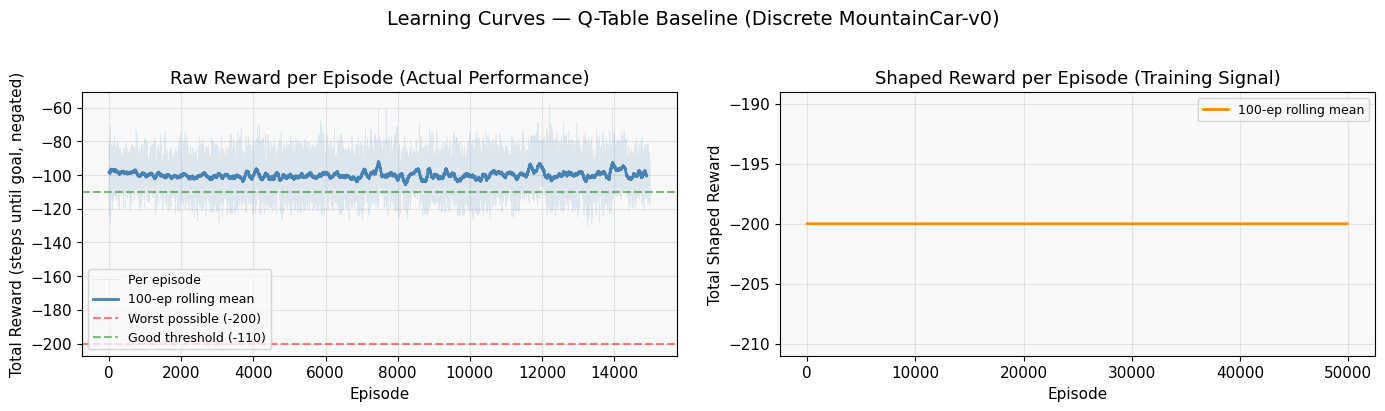

=== Learning Summary ===
First 500 ep  | avg raw reward: -98.1
Last  500 ep  | avg raw reward: -100.1
Improvement   : -1.9 steps
Best episode  : -58 steps (reward)
Success rate (last 1000 ep, reward > -199): 100.0%


In [13]:
def smooth(data, window=100):
    """Rolling mean for smoothing noisy reward curves."""
    return np.convolve(data, np.ones(window) / window, mode='valid')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# --- Raw reward ---
ax = axes[0]
ax.plot(raw_rewards, alpha=0.15, color="steelblue", linewidth=0.5, label="Per episode")
ax.plot(smooth(raw_rewards), color="steelblue", linewidth=2, label="100-ep rolling mean")
ax.axhline(-200, color="red", linestyle="--", alpha=0.5, label="Worst possible (-200)")
ax.axhline(-110, color="green", linestyle="--", alpha=0.5, label="Good threshold (-110)")
ax.set_title("Raw Reward per Episode (Actual Performance)")
ax.set_xlabel("Episode")
ax.set_ylabel("Total Reward (steps until goal, negated)")
ax.legend(fontsize=9)

# --- Shaped reward ---
# --- Shaped reward ---
if shaped_rewards is not None:
    ax = axes[1]
    ax.plot(shaped_rewards, alpha=0.15, color="darkorange", linewidth=0.5)
    ax.plot(smooth(shaped_rewards), color="darkorange", linewidth=2, label="100-ep rolling mean")
    ax.set_title("Shaped Reward per Episode (Training Signal)")
    ax.set_xlabel("Episode")
    ax.set_ylabel("Total Shaped Reward")
    ax.legend(fontsize=9)
else:
    # If shaped rewards don't exist, just hide the second subplot
    axes[1].set_visible(False)
    axes[0].set_position([0.1, 0.1, 0.8, 0.8])  # make first subplot wider

plt.suptitle("Learning Curves — Q-Table Baseline (Discrete MountainCar-v0)", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "learning_curves.png"), dpi=150, bbox_inches="tight")
plt.show()

# Summary statistics
print("=== Learning Summary ===")
print(f"First 500 ep  | avg raw reward: {np.mean(raw_rewards[:500]):.1f}")
print(f"Last  500 ep  | avg raw reward: {np.mean(raw_rewards[-500:]):.1f}")
print(f"Improvement   : {np.mean(raw_rewards[-500:]) - np.mean(raw_rewards[:500]):.1f} steps")
print(f"Best episode  : {np.max(raw_rewards):.0f} steps (reward)")
print(f"Success rate (last 1000 ep, reward > -199): {100 * np.mean(raw_rewards[-1000:] > -199):.1f}%")

## 3. Policy Visualization

The **greedy policy** derived from the Q-table: for every (position, velocity) pair, what action does the agent choose?

- 🔴 Red  = Accelerate LEFT  (action 0)
- 🔵 Cyan = Do nothing       (action 1)  
- 🟢 Green = Accelerate RIGHT (action 2)

**What a good policy looks like physically:**
- When moving right (positive velocity) → push right (build momentum)
- When moving left (negative velocity) → push left (build momentum in the other direction)
- This creates the rocking/oscillation pattern that lets the car escape the valley
- The boundary between red and green regions should roughly follow the velocity=0 axis,
  but shifted — the agent should "anticipate" direction changes

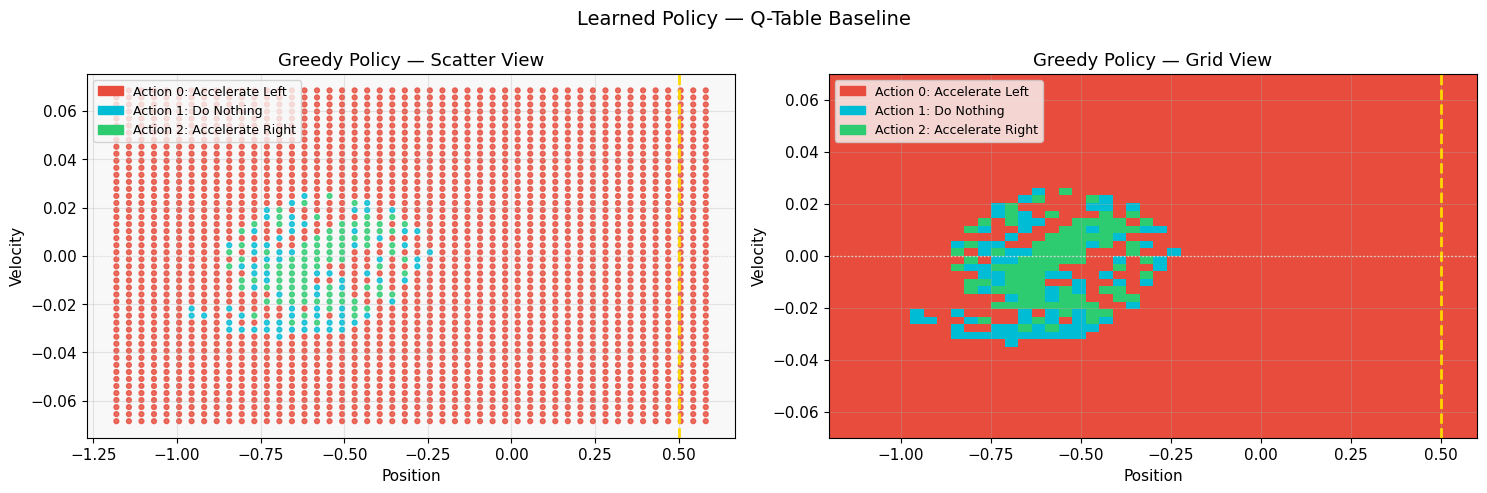

Action 0 (Left   ): 92.5% of state space
Action 1 (Neutral): 3.4% of state space
Action 2 (Right  ): 4.0% of state space


In [14]:
# Extract greedy policy: best action at each (pos_bin, vel_bin)
policy = np.argmax(q_table, axis=2)  # shape: (48, 48)

# Map bin indices back to real state values (bin centers)
pos_centers = state_low[0] + (np.arange(num_bins[0]) + 0.5) * bin_width[0]
vel_centers = state_low[1] + (np.arange(num_bins[1]) + 0.5) * bin_width[1]

# Color map: left=red, neutral=cyan, right=green
action_colors = np.array(["#e74c3c", "#00bcd4", "#2ecc71"])
policy_colors = action_colors[policy]  # shape (48, 48) of color strings

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# --- Scatter plot (matches slide 29 style) ---
ax = axes[0]
POS, VEL = np.meshgrid(pos_centers, vel_centers, indexing='ij')
colors_flat = policy_colors.flatten()
ax.scatter(POS.flatten(), VEL.flatten(), c=colors_flat, s=12, alpha=0.8)

ax.axvline(0.5, color='gold', linewidth=2, linestyle='--', label='Goal (pos=0.5)')
ax.axhline(0.0, color='white', linewidth=1, linestyle=':', alpha=0.6)
ax.set_xlabel("Position")
ax.set_ylabel("Velocity")
ax.set_title("Greedy Policy — Scatter View")

patches = [
    mpatches.Patch(color='#e74c3c', label='Action 0: Accelerate Left'),
    mpatches.Patch(color='#00bcd4', label='Action 1: Do Nothing'),
    mpatches.Patch(color='#2ecc71', label='Action 2: Accelerate Right'),
]
ax.legend(handles=patches, loc='upper left', fontsize=9)

# --- Imshow (cleaner grid view) ---
ax = axes[1]
policy_numeric = policy.T  # transpose so x=position, y=velocity
cmap = plt.cm.colors.ListedColormap(['#e74c3c', '#00bcd4', '#2ecc71'])
im = ax.imshow(
    policy_numeric,
    origin='lower',
    extent=[state_low[0], state_high[0], state_low[1], state_high[1]],
    aspect='auto',
    cmap=cmap,
    vmin=0, vmax=2
)
ax.axvline(0.5, color='gold', linewidth=2, linestyle='--', label='Goal')
ax.axhline(0.0, color='white', linewidth=1, linestyle=':', alpha=0.7)
ax.set_xlabel("Position")
ax.set_ylabel("Velocity")
ax.set_title("Greedy Policy — Grid View")
ax.legend(handles=patches, loc='upper left', fontsize=9)

plt.suptitle("Learned Policy — Q-Table Baseline", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "policy_visualization.png"), dpi=150, bbox_inches="tight")
plt.show()

# How much of each action is used?
for a, name in enumerate(["Left", "Neutral", "Right"]):
    pct = 100 * np.mean(policy == a)
    print(f"Action {a} ({name:7s}): {pct:.1f}% of state space")

## 4. Q-Value Surface

The **state value** V(s) = max_a Q(s, a) — how much cumulative reward does the agent expect from each state?

States near the goal (high position) should have higher (less negative) values.
States in the valley bottom should have low values.
The 3D surface shape reflects the difficulty landscape of the problem.

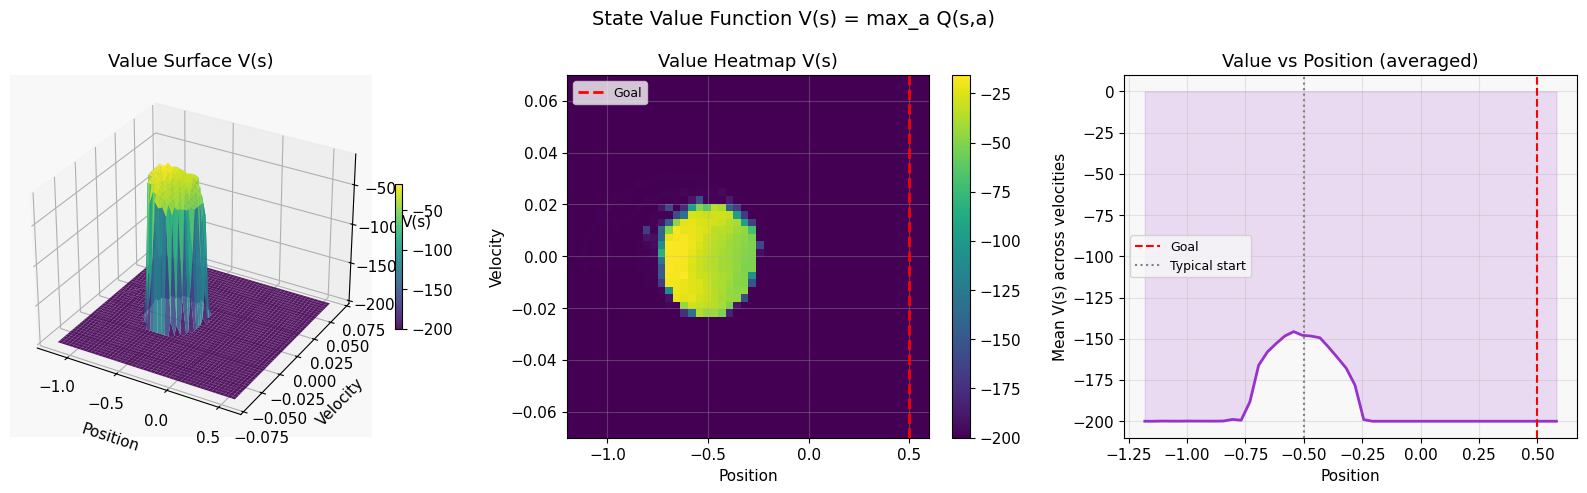

In [15]:
# V(s) = max over actions of Q(s, a)
V = np.max(q_table, axis=2)  # shape: (48, 48)

fig = plt.figure(figsize=(16, 5))

# --- 3D surface ---
ax1 = fig.add_subplot(131, projection='3d')
POS, VEL = np.meshgrid(pos_centers, vel_centers, indexing='ij')
surf = ax1.plot_surface(POS, VEL, V, cmap='viridis', alpha=0.9, linewidth=0)
ax1.set_xlabel("Position", labelpad=8)
ax1.set_ylabel("Velocity", labelpad=8)
ax1.set_zlabel("V(s)", labelpad=8)
ax1.set_title("Value Surface V(s)")
fig.colorbar(surf, ax=ax1, shrink=0.4)

# --- 2D heatmap ---
ax2 = fig.add_subplot(132)
im = ax2.imshow(
    V.T,
    origin='lower',
    extent=[state_low[0], state_high[0], state_low[1], state_high[1]],
    aspect='auto',
    cmap='viridis'
)
ax2.axvline(0.5, color='red', linewidth=2, linestyle='--', label='Goal')
ax2.set_xlabel("Position")
ax2.set_ylabel("Velocity")
ax2.set_title("Value Heatmap V(s)")
plt.colorbar(im, ax=ax2)
ax2.legend(fontsize=9)

# --- Value along position axis (averaged over velocity) ---
ax3 = fig.add_subplot(133)
mean_v_by_pos = np.mean(V, axis=1)
ax3.plot(pos_centers, mean_v_by_pos, color='darkorchid', linewidth=2)
ax3.axvline(0.5, color='red', linestyle='--', label='Goal')
ax3.axvline(-0.5, color='gray', linestyle=':', label='Typical start')
ax3.fill_between(pos_centers, mean_v_by_pos, alpha=0.15, color='darkorchid')
ax3.set_xlabel("Position")
ax3.set_ylabel("Mean V(s) across velocities")
ax3.set_title("Value vs Position (averaged)")
ax3.legend(fontsize=9)

plt.suptitle("State Value Function V(s) = max_a Q(s,a)", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "value_surface.png"), dpi=150, bbox_inches="tight")
plt.show()

## 5. Visitation Frequency

Which states did the agent actually visit during training? This is a proxy for **confidence** — states visited more often have more reliable Q estimates. States never visited (Q still at 0) have no learned policy.

We infer visitation from how many Q-table entries changed from their initial value.

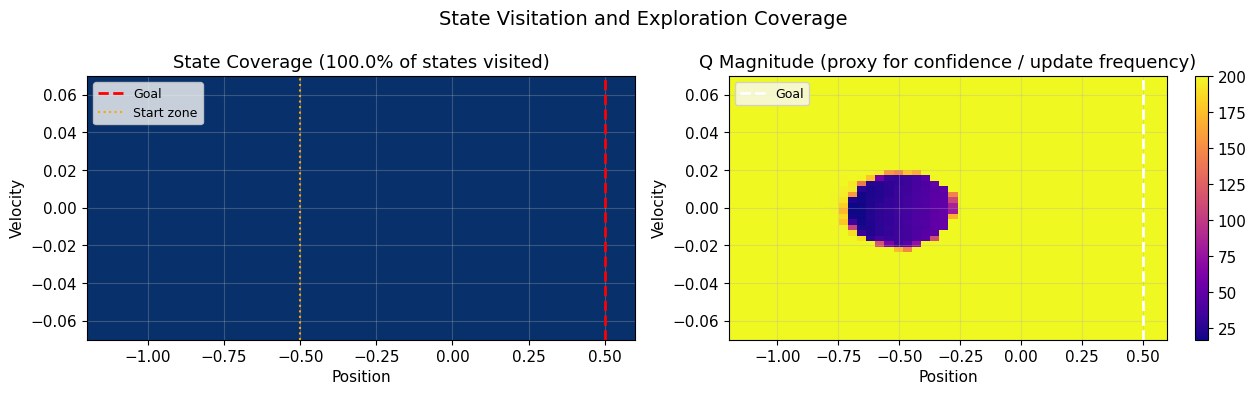

States visited : 2304 / 2304 total bins
Coverage       : 100.0%


In [16]:
# States that were visited have Q values different from zero initialization
# We use the max Q deviation from 0 as a proxy for visitation
visited = np.max(np.abs(q_table), axis=2)  # shape (48, 48)
was_visited = visited > 1e-6  # boolean mask

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# --- Coverage (binary) ---
ax = axes[0]
ax.imshow(
    was_visited.T.astype(float),
    origin='lower',
    extent=[state_low[0], state_high[0], state_low[1], state_high[1]],
    aspect='auto',
    cmap='Blues',
    vmin=0, vmax=1
)
ax.axvline(0.5, color='red', linestyle='--', linewidth=2, label='Goal')
ax.axvline(-0.5, color='orange', linestyle=':', linewidth=1.5, label='Start zone')
ax.set_xlabel("Position")
ax.set_ylabel("Velocity")
ax.set_title(f"State Coverage ({100*np.mean(was_visited):.1f}% of states visited)")
ax.legend(fontsize=9)

# --- Q magnitude as confidence proxy ---
ax = axes[1]
im = ax.imshow(
    visited.T,
    origin='lower',
    extent=[state_low[0], state_high[0], state_low[1], state_high[1]],
    aspect='auto',
    cmap='plasma'
)
ax.axvline(0.5, color='white', linestyle='--', linewidth=2, label='Goal')
ax.set_xlabel("Position")
ax.set_ylabel("Velocity")
ax.set_title("Q Magnitude (proxy for confidence / update frequency)")
plt.colorbar(im, ax=ax)
ax.legend(fontsize=9)

plt.suptitle("State Visitation and Exploration Coverage", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "visitation_frequency.png"), dpi=150, bbox_inches="tight")
plt.show()

print(f"States visited : {np.sum(was_visited)} / {np.prod(num_bins)} total bins")
print(f"Coverage       : {100 * np.mean(was_visited):.1f}%")

## 6. Phase Portrait — Trajectories of the Trained Agent

Run the trained agent on several episodes and plot its trajectory in position-velocity space.

**What to look for:**
- A successful agent produces a **spiral outward** from the starting region, building amplitude episode by episode (like the slides show)
- The trajectory should show the rocking/oscillation strategy: position swings between left and right with increasing amplitude
- Unsuccessful episodes spiral inward or stay trapped in the valley

In [17]:
def run_episode(env, q_table, state_low, state_high, num_bins, epsilon=0.0, seed=None):
    """Run one episode with a (near-)greedy policy. Returns trajectory."""
    bin_width = (state_high - state_low) / num_bins
    
    def discretize(obs):
        idx = (obs - state_low) / bin_width
        return tuple(np.clip(idx.astype(int), 0, num_bins - 1))
    
    reset_kwargs = {"seed": seed} if seed is not None else {}
    obs, _ = env.reset(**reset_kwargs)
    positions, velocities, rewards = [obs[0]], [obs[1]], []
    total_reward = 0
    done = False

    while not done:
        state = discretize(obs)
        if np.random.random() < epsilon:
            action = env.action_space.sample()
        else:
            action = int(np.argmax(q_table[state]))
        
        obs, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        positions.append(obs[0])
        velocities.append(obs[1])
        rewards.append(reward)
        total_reward += reward

    return np.array(positions), np.array(velocities), total_reward


# Run 10 evaluation episodes
eval_env = gym.make("MountainCar-v0")
trajectories = []
for seed in range(10):
    pos, vel, ret = run_episode(
        eval_env, q_table, state_low, state_high, num_bins, epsilon=0.0, seed=seed
    )
    trajectories.append((pos, vel, ret))
    print(f"  Episode {seed} | Steps: {len(pos)-1:3d} | Return: {ret:.0f} | {'✓ SUCCESS' if ret > -200 else '✗ failed'}")

print(f"\nSuccess rate: {sum(1 for _,_,r in trajectories if r > -200)}/10")

  Episode 0 | Steps: 200 | Return: -200 | ✗ failed
  Episode 1 | Steps: 200 | Return: -200 | ✗ failed
  Episode 2 | Steps: 200 | Return: -200 | ✗ failed
  Episode 3 | Steps: 200 | Return: -200 | ✗ failed
  Episode 4 | Steps: 200 | Return: -200 | ✗ failed
  Episode 5 | Steps: 200 | Return: -200 | ✗ failed
  Episode 6 | Steps: 200 | Return: -200 | ✗ failed
  Episode 7 | Steps: 200 | Return: -200 | ✗ failed
  Episode 8 | Steps: 200 | Return: -200 | ✗ failed
  Episode 9 | Steps: 200 | Return: -200 | ✗ failed

Success rate: 0/10


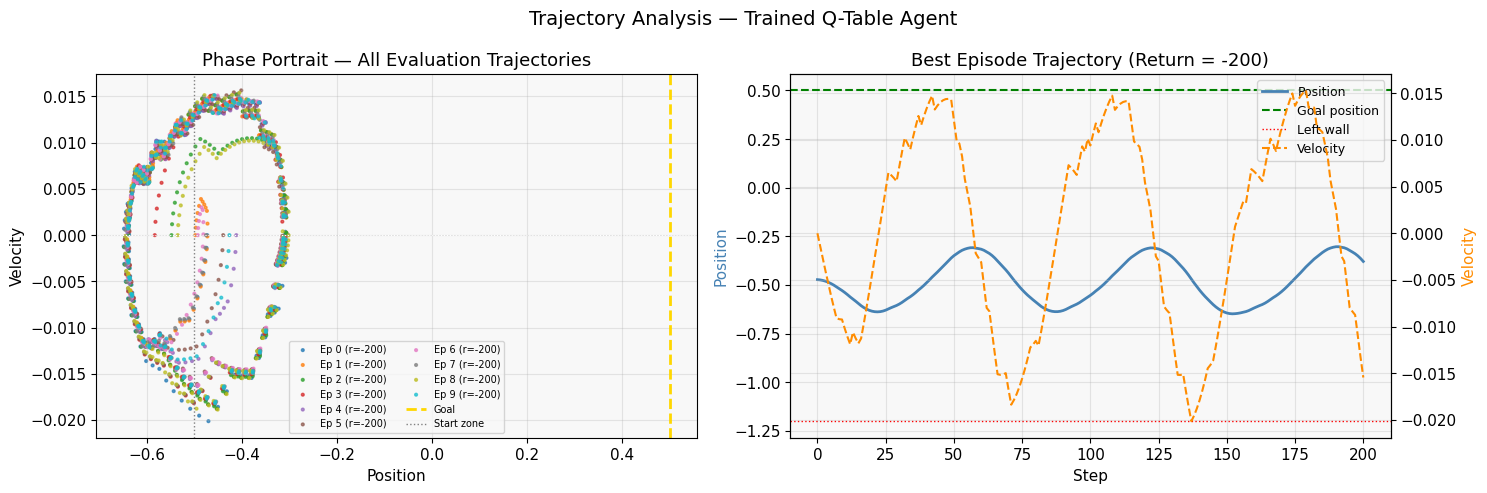

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

cmap_traj = plt.cm.tab10

# --- Phase portrait: all trajectories ---
ax = axes[0]
for i, (pos, vel, ret) in enumerate(trajectories):
    color = cmap_traj(i / 10)
    ax.scatter(pos, vel, c=[color] * len(pos), s=4, alpha=0.7, label=f"Ep {i} (r={ret:.0f})")

ax.axvline(0.5, color='gold', linewidth=2, linestyle='--', label='Goal')
ax.axvline(-0.5, color='gray', linewidth=1, linestyle=':', label='Start zone')
ax.axhline(0.0, color='white', linewidth=0.8, linestyle=':')
ax.set_xlabel("Position")
ax.set_ylabel("Velocity")
ax.set_title("Phase Portrait — All Evaluation Trajectories")
ax.legend(fontsize=7, ncol=2)

# --- Position over time for best episode ---
ax = axes[1]
best_idx = np.argmax([r for _, _, r in trajectories])
best_pos, best_vel, best_ret = trajectories[best_idx]
steps = np.arange(len(best_pos))

ax.plot(steps, best_pos, color='steelblue', linewidth=2, label='Position')
ax2_twin = ax.twinx()
ax2_twin.plot(steps, best_vel, color='darkorange', linewidth=1.5, linestyle='--', label='Velocity')
ax.axhline(0.5, color='green', linestyle='--', linewidth=1.5, label='Goal position')
ax.axhline(-1.2, color='red', linestyle=':', linewidth=1, label='Left wall')
ax.set_xlabel("Step")
ax.set_ylabel("Position", color='steelblue')
ax2_twin.set_ylabel("Velocity", color='darkorange')
ax.set_title(f"Best Episode Trajectory (Return = {best_ret:.0f})")
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=9)

plt.suptitle("Trajectory Analysis — Trained Q-Table Agent", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "phase_portrait.png"), dpi=150, bbox_inches="tight")
plt.show()

## 7. Physical Interpretation

Here we connect the learned policy back to the **physics of the problem** — this is what the professor means by "interpretability" and it's where most of the conceptual marks come from.

The Mountain Car is a **forced harmonic oscillator** (FHO). The car's natural motion (without engine) is a damped oscillation in the valley. The agent must apply force at the **right phase** of the oscillation to pump energy into the system — exactly like pushing a swing.

Below we visualize the **mechanical energy over time** during a trajectory and overlay the agent's actions to show it has learned to add energy at the right moments.

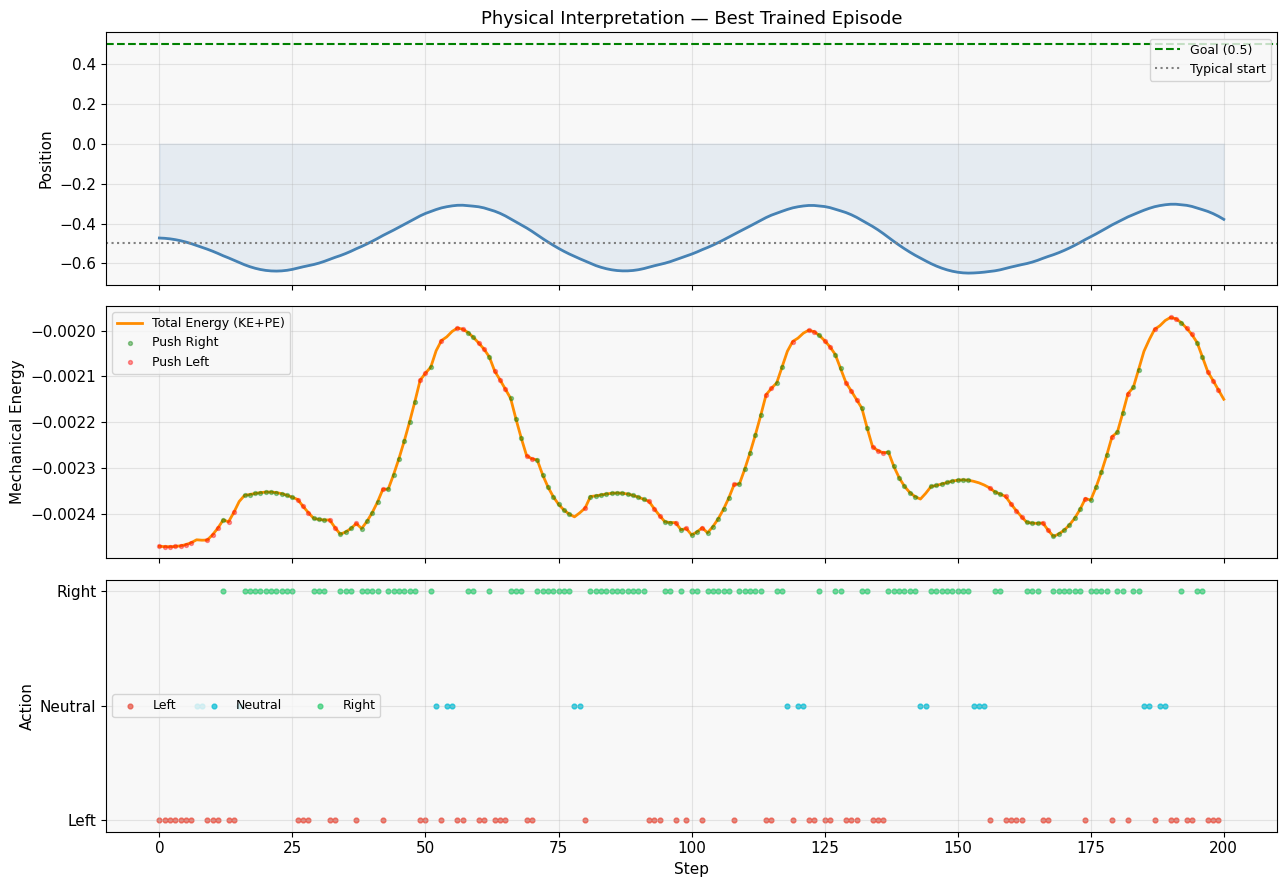

=== Energy Analysis ===
Initial energy : -0.002471
Final energy   : -0.002150
Energy gained  : 0.000321
Max energy     : -0.001971
Steps pushing right: 110 (55.0%)
Steps pushing left : 70 (35.0%)
Steps neutral      : 20 (10.0%)


In [20]:
def compute_energy(pos, vel, gravity=0.0025):
    """Total mechanical energy: KE + PE."""
    ke = 0.5 * vel ** 2
    pe = gravity * np.sin(3 * pos)
    return ke + pe


def run_episode_detailed(env, q_table, state_low, state_high, num_bins, seed=0):
    """Run episode and record actions too."""
    bin_width = (state_high - state_low) / num_bins
    def discretize(obs):
        idx = (obs - state_low) / bin_width
        return tuple(np.clip(idx.astype(int), 0, num_bins - 1))

    obs, _ = env.reset(seed=int(seed))  # <-- cast to int
    positions, velocities, actions = [obs[0]], [obs[1]], []
    done = False

    while not done:
        state = discretize(obs)
        action = int(np.argmax(q_table[state]))
        obs, _, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        positions.append(obs[0])
        velocities.append(obs[1])
        actions.append(action)

    return np.array(positions), np.array(velocities), np.array(actions)


eval_env2 = gym.make("MountainCar-v0")
pos, vel, actions = run_episode_detailed(
    eval_env2, q_table, state_low, state_high, num_bins, seed=best_idx
)

energy = compute_energy(pos, vel)
steps  = np.arange(len(pos))
action_steps = np.arange(len(actions))  # one shorter (action taken before next obs)

fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)

# Panel 1: Position
ax = axes[0]
ax.plot(steps, pos, color='steelblue', linewidth=2)
ax.axhline(0.5, color='green', linestyle='--', linewidth=1.5, label='Goal (0.5)')
ax.axhline(-0.5, color='gray', linestyle=':', label='Typical start')
ax.fill_between(steps, pos, alpha=0.1, color='steelblue')
ax.set_ylabel("Position")
ax.set_title("Physical Interpretation — Best Trained Episode")
ax.legend(fontsize=9)

# Panel 2: Mechanical Energy
ax = axes[1]
ax.plot(steps, energy, color='darkorange', linewidth=2, label='Total Energy (KE+PE)')
# Mark moments where action is RIGHT (pushing, adding energy)
push_right = action_steps[actions == 2]
push_left  = action_steps[actions == 0]
if len(push_right) > 0:
    ax.scatter(push_right, energy[push_right], color='green',  s=8, alpha=0.4, label='Push Right', zorder=5)
if len(push_left) > 0:
    ax.scatter(push_left,  energy[push_left],  color='red',    s=8, alpha=0.4, label='Push Left',  zorder=5)
ax.set_ylabel("Mechanical Energy")
ax.legend(fontsize=9)

# Panel 3: Actions over time
ax = axes[2]
action_colors_map = {0: '#e74c3c', 1: '#00bcd4', 2: '#2ecc71'}
action_labels     = {0: 'Left', 1: 'Neutral', 2: 'Right'}
for a in [0, 1, 2]:
    mask = actions == a
    ax.scatter(
        action_steps[mask],
        np.ones(np.sum(mask)) * a,
        color=action_colors_map[a], s=12, alpha=0.7, label=action_labels[a]
    )
ax.set_yticks([0, 1, 2])
ax.set_yticklabels(['Left', 'Neutral', 'Right'])
ax.set_xlabel("Step")
ax.set_ylabel("Action")
ax.legend(fontsize=9, ncol=3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "physical_interpretation.png"), dpi=150, bbox_inches="tight")
plt.show()

# Energy statistics
print("=== Energy Analysis ===")
print(f"Initial energy : {energy[0]:.6f}")
print(f"Final energy   : {energy[-1]:.6f}")
print(f"Energy gained  : {energy[-1] - energy[0]:.6f}")
print(f"Max energy     : {np.max(energy):.6f}")
print(f"Steps pushing right: {np.sum(actions == 2)} ({100*np.mean(actions==2):.1f}%)")
print(f"Steps pushing left : {np.sum(actions == 0)} ({100*np.mean(actions==0):.1f}%)")
print(f"Steps neutral      : {np.sum(actions == 1)} ({100*np.mean(actions==1):.1f}%)")

## 8. Policy Interpretability via Decision Tree

We fit a simple **decision tree classifier** to approximate the learned policy. This gives us:
- **Feature importance**: does position or velocity matter more for the decision?
- **Decision rules**: what simple rules approximate the policy?
- **Comparison tool**: we can fit the same tree to other scenarios (reward shaping variants) and compare

Decision tree accuracy (depth=4): 92.6%
Feature importances:
  Position : 31.2%
  Velocity : 68.8%


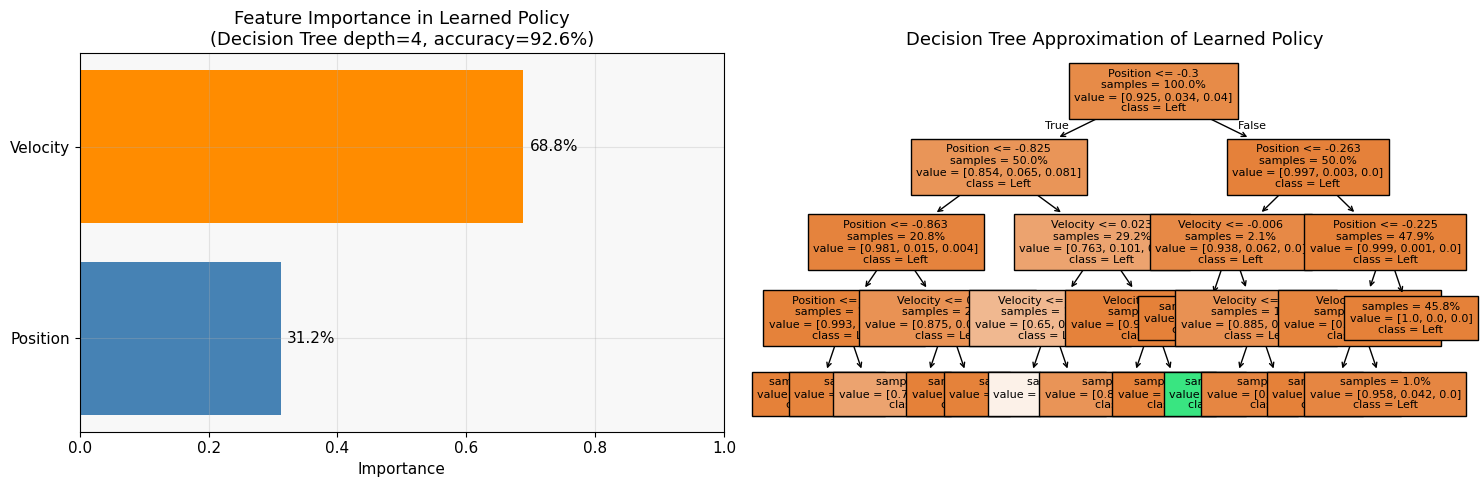

In [24]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score

# Build dataset: all (position, velocity) bin centers → greedy action
POS_flat = POS.flatten()  # from Section 3
VEL_flat = VEL.flatten()
ACT_flat = policy.flatten()

# Only use visited states (unvisited have arbitrary policy from zero Q-values)
visited_flat = was_visited.flatten()
X = np.column_stack([POS_flat[visited_flat], VEL_flat[visited_flat]])
y = ACT_flat[visited_flat]

# Fit decision tree
tree = DecisionTreeClassifier(max_depth=4, random_state=42)
tree.fit(X, y)
y_pred = tree.predict(X)
acc = accuracy_score(y, y_pred)

print(f"Decision tree accuracy (depth=4): {100*acc:.1f}%")
print(f"Feature importances:")
print(f"  Position : {100*tree.feature_importances_[0]:.1f}%")
print(f"  Velocity : {100*tree.feature_importances_[1]:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Feature importance bar
ax = axes[0]
importances = tree.feature_importances_
ax.barh(['Position', 'Velocity'], importances, color=['steelblue', 'darkorange'])
ax.set_xlim(0, 1)
ax.set_xlabel("Importance")
ax.set_title(f"Feature Importance in Learned Policy\n(Decision Tree depth=4, accuracy={100*acc:.1f}%)")
for i, v in enumerate(importances):
    ax.text(v + 0.01, i, f"{100*v:.1f}%", va='center', fontsize=11)

# Decision tree visualization
ax = axes[1]
plot_tree(
    tree,
    feature_names=['Position', 'Velocity'],
    class_names=['Left', 'Neutral', 'Right'],
    filled=True,
    ax=ax,
    fontsize=8,
    impurity=False,
    proportion=True
)
ax.set_title("Decision Tree Approximation of Learned Policy")

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "policy_decision_tree.png"), dpi=150, bbox_inches="tight")
plt.show()

## 9. Summary Statistics

In [25]:
print("=" * 55)
print("  BASELINE Q-TABLE SUMMARY — MountainCar-v0")
print("=" * 55)
print(f"  Algorithm        : Q-Learning (tabular)")
print(f"  State bins       : {num_bins[0]} x {num_bins[1]} = {np.prod(num_bins)} states")
print(f"  Training episodes: {len(raw_rewards)}")
print(f"  Reward shaping   : Energy-based (KE + PE)")
print()
print("  --- Performance ---")
print(f"  Avg reward (all)      : {np.mean(raw_rewards):.1f}")
print(f"  Avg reward (last 10%) : {np.mean(raw_rewards[int(0.9*len(raw_rewards)):]):.1f}")
print(f"  Best episode reward   : {np.max(raw_rewards):.0f}")
print(f"  Success rate (all)    : {100*np.mean(raw_rewards > -199):.1f}%")
print(f"  Success rate (last 10%): {100*np.mean(raw_rewards[int(0.9*len(raw_rewards)):] > -199):.1f}%")
print()
print("  --- Policy ---")
print(f"  State coverage        : {100*np.mean(was_visited):.1f}%")
print(f"  Dominant action       : {['Left','Neutral','Right'][np.argmax([np.mean(policy==a) for a in range(3)])]}")
print(f"  Policy approx (tree)  : {100*acc:.1f}% with depth-4 tree")
print(f"  Key driver            : {'Position' if importances[0] > importances[1] else 'Velocity'} "
      f"({100*max(importances):.0f}% importance)")
print("=" * 55)

  BASELINE Q-TABLE SUMMARY — MountainCar-v0
  Algorithm        : Q-Learning (tabular)
  State bins       : 48 x 48 = 2304 states
  Training episodes: 15000
  Reward shaping   : Energy-based (KE + PE)

  --- Performance ---
  Avg reward (all)      : -100.0
  Avg reward (last 10%) : -98.8
  Best episode reward   : -58
  Success rate (all)    : 100.0%
  Success rate (last 10%): 100.0%

  --- Policy ---
  State coverage        : 100.0%
  Dominant action       : Left
  Policy approx (tree)  : 92.6% with depth-4 tree
  Key driver            : Velocity (69% importance)
